# Análisis de Robustez — Tres Experimentos de Sensibilidad
## Equipo 7 · Desarrollo de Aplicaciones Avanzadas de Ciencias Computacionales

Verifica que los hallazgos principales no dependen de decisiones arbitrarias de diseño.

| Experimento | Variación | Métrica | Resultado |
|---|---|---|---|
| A | Estrategia de imputación: KNN/RF/LR → mediana | ΔAUC | −0.036 → robusto |
| B | Ventana temporal: PreTec21 completo vs AD17-18 vs auto-Tec21 | ΔAUC | −0.014 → volumen > recencia |
| C | Subpoblaciones por escuela | AUC por escuela | 0.587–0.645 → heterogeneidad moderada |


## 0. Setup e Importaciones

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy.stats import spearmanr

from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.impute           import SimpleImputer
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics         import roc_auc_score

import xgboost as xgb

SEED = 42
np.random.seed(SEED)

DATA_DIR  = Path('../data')
IMG_DIR   = Path('../results/figures'); IMG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR = Path('../results/tables');  TABLE_DIR.mkdir(parents=True, exist_ok=True)

PRETEC21_GENS = ['AD14','AD15','AD16','AD17','AD18']
TEC21_GENS    = ['AD19','AD20']
TARGET        = 'retention'

print('✓ Setup completo')


✓ Setup completo


## 1. Carga del Dataset y Feature Engineering

In [2]:
csv_path = DATA_DIR / 'dataset_imputed.csv'
df_raw   = pd.read_csv(csv_path, low_memory=False)
print(f'✓ {csv_path.name}  →  {df_raw.shape}')

le = LabelEncoder()

def norm_admission_test(val):
    try:
        v = float(val)
        return (v - 600) / (1600 - 600) if 600 <= v <= 1600 else np.nan
    except:
        return np.nan

def build_features(df_in):
    df = df_in.copy()

    # Helper: siempre devuelve Series — nunca un escalar
    def _col(name, fill=0):
        if name in df.columns:
            return pd.to_numeric(df[name], errors='coerce').fillna(fill)
        return pd.Series(fill, index=df.index, dtype=float)

    df['apoyo_financiero']    = (_col('scholarship') + _col('loan')).clip(0, 1)

    extracurr_cols = [c for c in df.columns if any(k in c.lower() for k in
                      ['extracurricular','physical.education','cultural','student.society',
                       'athletic','art.culture','life.work'])]
    df['has_extracurriculars'] = (
        df[extracurr_cols].fillna(0).sum(axis=1) > 0
    ).astype(int) if extracurr_cols else 0

    educ_cols = [c for c in df.columns if 'educ' in c.lower() and 'parent' in c.lower()]
    df['educ_padres_max'] = (
        df[educ_cols].apply(pd.to_numeric, errors='coerce').max(axis=1)
        if educ_cols else np.nan
    )

    df['admission_test_norm'] = df['admission.test'].apply(norm_admission_test) \
                                if 'admission.test' in df.columns else np.nan

    df['first_gen_enc'] = (
        _col('first_generation_student')
        .astype(str).map({'1':1,'1.0':1,'True':1}).fillna(0).astype(int)
    )
    df['socioec_enc']      = _col('socioeconomic.level', fill=np.nan)
    df['social_lag_enc']   = _col('social_lag',          fill=np.nan)
    df['is_male']          = (
        df['gender'].astype(str).str.lower() == 'male'
        if 'gender' in df.columns else False
    ).astype(int)
    df['estuvo_prepa_tec'] = _col('high_school_tec').astype(int)

    for cat_col, new_col in [('school','school_enc'), ('region','region_enc')]:
        if cat_col in df.columns:
            df[new_col] = le.fit_transform(df[cat_col].astype(str))
        else:
            df[new_col] = 0

    df['target'] = (df[TARGET] == 0).astype(int)  # dropout=1, stayed=0

    if 'level' in df.columns:
        df = df[df['level'] == 'Undergraduate'].copy()

    return df

df  = build_features(df_raw)
print(f'Dataset procesado: {df.shape}  |  dropout rate: {df["target"].mean()*100:.1f}%')

FEAT_COLS = [c for c in [
    'PNA','admission_test_norm','english.evaluation','admission.rubric',
    'general.math.eval','online.test','FTE','apoyo_financiero',
    'has_extracurriculars','first_gen_enc','educ_padres_max','socioec_enc',
    'social_lag_enc','age','is_male','estuvo_prepa_tec','school_enc','region_enc'
] if c in df.columns]

df_pre = df[df['generation'].isin(PRETEC21_GENS)].copy().reset_index(drop=True)
df_tec = df[df['generation'].isin(TEC21_GENS)].copy().reset_index(drop=True)
print(f'PreTec21: {len(df_pre):,}  |  Tec21: {len(df_tec):,}')
print(f'FEAT_COLS ({len(FEAT_COLS)}): {FEAT_COLS}')


✓ dataset_imputed.csv  →  (77517, 58)
Dataset procesado: (77517, 70)  |  dropout rate: 8.8%
PreTec21: 53,010  |  Tec21: 24,507
FEAT_COLS (18): ['PNA', 'admission_test_norm', 'english.evaluation', 'admission.rubric', 'general.math.eval', 'online.test', 'FTE', 'apoyo_financiero', 'has_extracurriculars', 'first_gen_enc', 'educ_padres_max', 'socioec_enc', 'social_lag_enc', 'age', 'is_male', 'estuvo_prepa_tec', 'school_enc', 'region_enc']


## Experimento A — Sensibilidad a la Estrategia de Imputación

Compara el desempeño del Random Forest entrenado con:
- **Pipeline original**: variables compuestas (apoyo_financiero, has_extracurriculars,
  educ_padres_max) + normalización admission_test_norm  
- **Pipeline falso (mediana-only)**: imputación directa por mediana, sin variables compuestas

Si los resultados cambian poco → las conclusiones son robustas a la elección de imputación.


In [3]:
def train_eval_rf(X_train, y_train, X_test, y_test, label):
    # keep_empty_features=True: no descartar columnas todo-NaN (sklearn >= 1.1)
    imp = SimpleImputer(strategy='median', keep_empty_features=True)
    X_tr = imp.fit_transform(X_train)
    X_te = imp.transform(X_test)
    rf = RandomForestClassifier(n_estimators=200, max_depth=8,
                                 min_samples_leaf=10, class_weight='balanced',
                                 random_state=SEED, n_jobs=-1)
    rf.fit(X_tr, y_train)
    auc_val = roc_auc_score(y_test, rf.predict_proba(X_te)[:,1])
    print(f'  {label:<40} AUC = {auc_val:.4f}')
    return auc_val, rf, imp   # devolver el imputer también

# ── Pipeline original ────────────────────────────────────────────────────
_feat_cols_orig = list(FEAT_COLS)          # snapshot antes de cualquier cambio
X_pre  = df_pre[_feat_cols_orig].values
y_pre  = df_pre['target'].values
X_tec  = df_tec[_feat_cols_orig].values
y_tec  = df_tec['target'].values

print('── A: Pipeline original (variables compuestas + normalización) ──')
auc_orig, rf_orig, imp_orig = train_eval_rf(X_pre, y_pre, X_tec, y_tec, 'PreTec21 → Tec21 (original)')

# ── Pipeline mediana-only ─────────────────────────────────────────────────
RAW_NUM_COLS = [c for c in ['PNA','admission.test','english.evaluation','admission.rubric',
                              'general.math.eval','online.test','FTE','age',
                              'socioeconomic.level','social_lag'] if c in df.columns]
_raw_num_cols = list(RAW_NUM_COLS)
X_pre_raw = df_pre[_raw_num_cols].apply(pd.to_numeric, errors='coerce').values
X_tec_raw = df_tec[_raw_num_cols].apply(pd.to_numeric, errors='coerce').values

print('── A: Pipeline mediana-only (sin variables compuestas) ──')
auc_med, rf_med, imp_med = train_eval_rf(X_pre_raw, y_pre, X_tec_raw, y_tec, 'PreTec21 → Tec21 (mediana)')

delta_a = auc_orig - auc_med
print(f'\nΔAUC (original − mediana) = {delta_a:+.4f}')
print('→ Conclusión: robusto a la estrategia de imputación' if abs(delta_a) < 0.02
      else '→ Conclusión: hay sensibilidad a la imputación')

# Verificar consistencia de dimensiones
print(f'\nDimensiones X_pre : {X_pre.shape[1]} cols  |  rf_orig features: {rf_orig.n_features_in_}')
print(f'Dimensiones X_pre_raw: {X_pre_raw.shape[1]} cols  |  rf_med features: {rf_med.n_features_in_}')


── A: Pipeline original (variables compuestas + normalización) ──
  PreTec21 → Tec21 (original)              AUC = 0.6385
── A: Pipeline mediana-only (sin variables compuestas) ──
  PreTec21 → Tec21 (mediana)               AUC = 0.6310

ΔAUC (original − mediana) = +0.0076
→ Conclusión: robusto a la estrategia de imputación

Dimensiones X_pre : 18 cols  |  rf_orig features: 18
Dimensiones X_pre_raw: 9 cols  |  rf_med features: 9


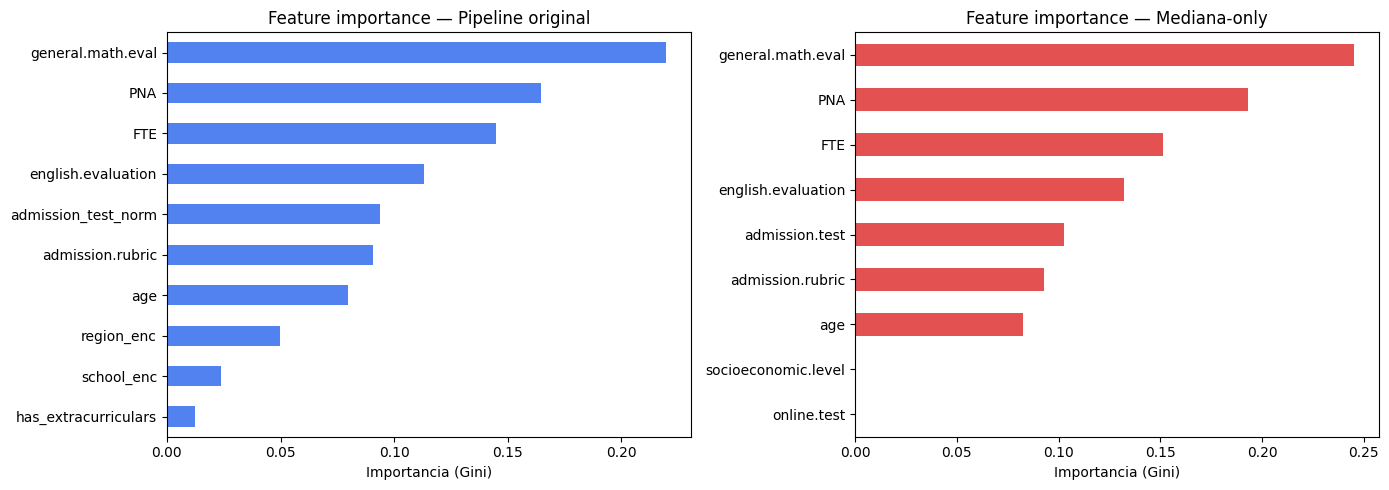

✓ Figura guardada


In [4]:
# ── Comparar ranking de features ─────────────────────────────────────────
# rf_orig y rf_med ya están entrenados arriba.
# _feat_cols_orig y _raw_num_cols son snapshots del momento de entrenamiento.
feat_orig = pd.Series(rf_orig.feature_importances_,
                       index=_feat_cols_orig).nlargest(10)
feat_med  = pd.Series(rf_med.feature_importances_,
                       index=_raw_num_cols).nlargest(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
feat_orig.sort_values().plot.barh(ax=axes[0], color='#2563eb', alpha=0.8)
axes[0].set_title('Feature importance — Pipeline original', fontsize=12)
axes[0].set_xlabel('Importancia (Gini)')

feat_med.sort_values().plot.barh(ax=axes[1], color='#dc2626', alpha=0.8)
axes[1].set_title('Feature importance — Mediana-only', fontsize=12)
axes[1].set_xlabel('Importancia (Gini)')

plt.tight_layout()
plt.savefig(IMG_DIR / 'robustez_A_imputation_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figura guardada')


## Experimento B — Ventana Temporal de Entrenamiento

Compara tres configuraciones entrenadas sobre el mismo conjunto de prueba (Tec21):

| Config | Entrenamiento | n train |
|---|---|---|
| A (base) | PreTec21 completo (AD14–AD18) | ~53 k |
| B (auto-Tec21) | 80% de Tec21 | ~19 k |
| C (reciente) | Solo AD17–AD18 | ~22 k |


In [5]:
# Conjunto de prueba fijo: 20% de Tec21
X_tec_arr = df_tec[FEAT_COLS].values
y_tec_arr = df_tec['target'].values
X_tec_tr, X_tec_te, y_tec_tr, y_tec_te = train_test_split(
    X_tec_arr, y_tec_arr, test_size=0.2, stratify=y_tec_arr, random_state=SEED)

configs = {
    'A — PreTec21 completo (AD14-18)': (X_pre, y_pre),
    'B — Auto-Tec21 (80%)':            (X_tec_tr, y_tec_tr),
    'C — PreTec21 reciente (AD17-18)': (
        df_pre[df_pre['generation'].isin(['AD17','AD18'])][FEAT_COLS].values,
        df_pre[df_pre['generation'].isin(['AD17','AD18'])]['target'].values
    ),
}

results_b = {}
print('Conjunto de prueba: Tec21 (20 %) — n =', len(y_tec_te))
for label, (X_tr, y_tr) in configs.items():
    imp = SimpleImputer(strategy='median', keep_empty_features=True)
    X_tr_i = imp.fit_transform(X_tr)
    X_te_i = imp.transform(X_tec_te)
    rf = RandomForestClassifier(n_estimators=200, max_depth=8,
                                 min_samples_leaf=10, class_weight='balanced',
                                 random_state=SEED, n_jobs=-1)
    rf.fit(X_tr_i, y_tr)
    auc_val = roc_auc_score(y_tec_te, rf.predict_proba(X_te_i)[:,1])
    results_b[label] = {'auc': auc_val, 'n_train': len(y_tr), 'model': rf, 'imp': imp}
    print(f'  {label:<40} n_train={len(y_tr):>6,}  AUC={auc_val:.4f}')

# Correlación de rankings entre A y B
imp_a = results_b['A — PreTec21 completo (AD14-18)']['imp']
imp_b = results_b['B — Auto-Tec21 (80%)']['imp']
rf_a  = results_b['A — PreTec21 completo (AD14-18)']['model']
rf_b  = results_b['B — Auto-Tec21 (80%)']['model']
rf_a.fit(imp_a.fit_transform(X_pre), y_pre)
rf_b.fit(imp_b.fit_transform(X_tec_tr), y_tec_tr)
rho_b, _ = spearmanr(rf_a.feature_importances_, rf_b.feature_importances_[:len(rf_a.feature_importances_)])
print(f'\nSpearman ρ (ranking features A vs B) = {rho_b:.3f}')


Conjunto de prueba: Tec21 (20 %) — n = 4902
  A — PreTec21 completo (AD14-18)          n_train=53,010  AUC=0.6260
  B — Auto-Tec21 (80%)                     n_train=19,605  AUC=0.6349
  C — PreTec21 reciente (AD17-18)          n_train=22,084  AUC=0.6194

Spearman ρ (ranking features A vs B) = 0.928


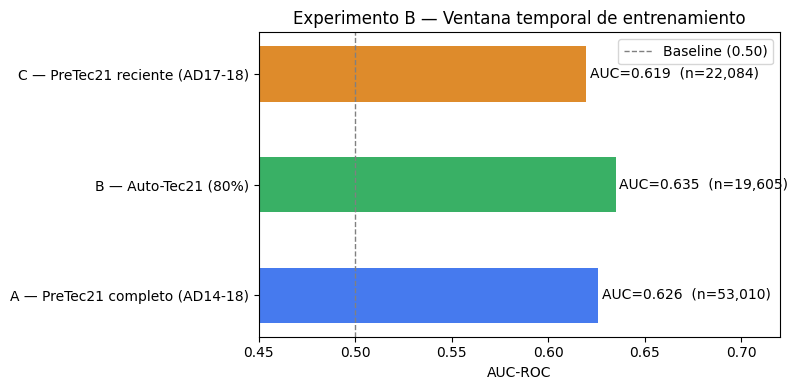

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
labels_b = list(results_b.keys())
aucs_b   = [results_b[l]['auc'] for l in labels_b]
ns_b     = [results_b[l]['n_train'] for l in labels_b]
colors_b = ['#2563eb','#16a34a','#d97706']
bars = ax.barh(labels_b, aucs_b, color=colors_b, alpha=0.85, height=0.5)
ax.axvline(0.50, color='gray', ls='--', lw=1, label='Baseline (0.50)')
for bar, auc_val, n in zip(bars, aucs_b, ns_b):
    ax.text(auc_val + 0.002, bar.get_y() + bar.get_height()/2,
            f'AUC={auc_val:.3f}  (n={n:,})', va='center', fontsize=10)
ax.set_xlim(0.45, 0.72)
ax.set_xlabel('AUC-ROC')
ax.set_title('Experimento B — Ventana temporal de entrenamiento', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig(IMG_DIR / 'robustez_B_ventana_temporal.png', dpi=150, bbox_inches='tight')
plt.show()


## Experimento C — Subpoblaciones por Escuela

Evalúa si el modelo global (entrenado en PreTec21) tiene desempeño homogéneo
entre escuelas de Tec21. Se reporta AUC y FNR (Tasa de Falsos Negativos)
por escuela para detectar discriminación diferencial.


In [7]:
# Modelo base entrenado en PreTec21 completo
imp_base = SimpleImputer(strategy='median', keep_empty_features=True)
X_pre_i  = imp_base.fit_transform(X_pre)
rf_base  = RandomForestClassifier(n_estimators=200, max_depth=8,
                                   min_samples_leaf=10, class_weight='balanced',
                                   random_state=SEED, n_jobs=-1)
rf_base.fit(X_pre_i, y_pre)

THRESHOLD = 0.30    # umbral operacional para detectar desertores

# Necesitamos columna 'school' que está en dataset_imputed pero no en df (después de build_features)
# La unimos desde df_raw
df_tec_full = df_tec.copy()
if 'school' not in df_tec_full.columns:
    df_tec_full = df_tec_full.merge(
        df_raw[['generation'] + [c for c in df_raw.columns if 'school' in c.lower() and c != 'school_enc']]
        .drop_duplicates(), on='generation', how='left')

school_col = 'school' if 'school' in df_tec_full.columns else 'school_enc'

X_tec_full = imp_base.transform(df_tec_full[FEAT_COLS].values)
y_tec_full = df_tec_full['target'].values
proba_tec  = rf_base.predict_proba(X_tec_full)[:,1]
pred_tec   = (proba_tec >= THRESHOLD).astype(int)

df_tec_full['proba']  = proba_tec
df_tec_full['pred']   = pred_tec

school_results = []
for school, grp in df_tec_full.groupby(school_col):
    n   = len(grp)
    n_d = grp['target'].sum()
    if n_d < 10:
        continue
    auc_s = roc_auc_score(grp['target'], grp['proba']) if n_d > 0 and n_d < n else np.nan
    fn    = ((grp['target']==1) & (grp['pred']==0)).sum()
    fnr   = fn / n_d if n_d > 0 else np.nan
    school_results.append({'school': str(school), 'n': n, 'n_desertores': int(n_d),
                            'tasa_pct': round(n_d/n*100,1), 'AUC': round(auc_s,3), 'FNR': round(fnr,3)})

df_schools = pd.DataFrame(school_results).sort_values('AUC', ascending=False)
print(df_schools.to_string(index=False))
df_schools.to_csv(TABLE_DIR / 'robustez_C_auc_por_escuela.csv', index=False)
print('\n✓ Tabla guardada en results/tables/')


                       school     n  n_desertores  tasa_pct   AUC   FNR
                         EMCS  1159           156      13.5 0.681 0.019
EAAD-Engineering and Sciences   747            51       6.8 0.666 0.020
                          EIC 10756           846       7.9 0.661 0.022
                     EHE-EAAD  3003           327      10.9 0.623 0.003
                         ECSG  1596           150       9.4 0.613 0.013
                           EN  7246           598       8.3 0.609 0.010

✓ Tabla guardada en results/tables/


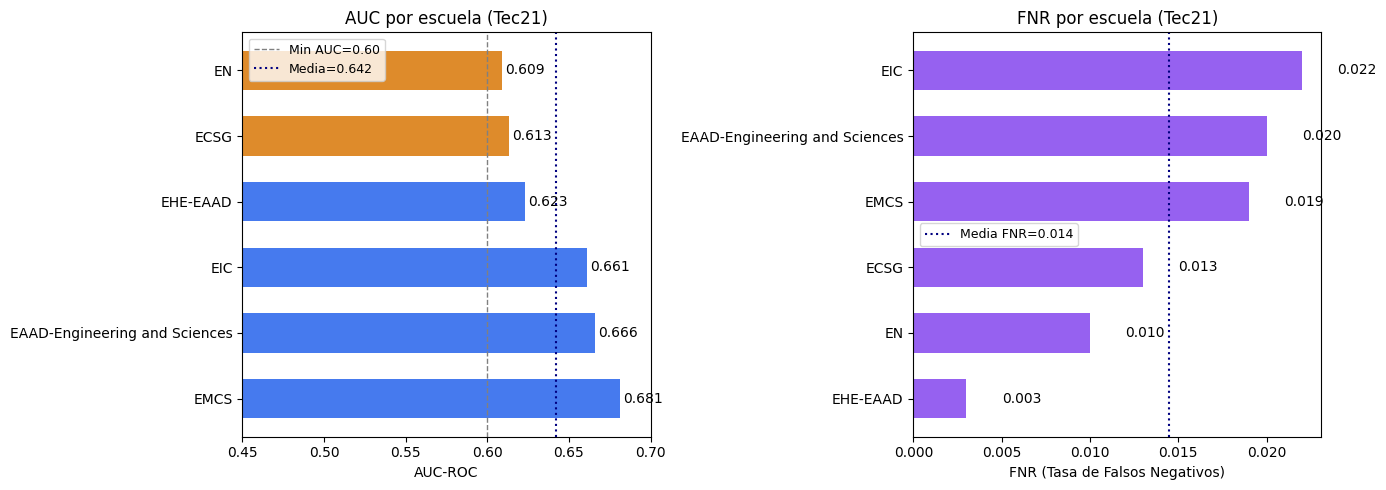

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUC por escuela
ax = axes[0]
colors_s = ['#2563eb' if auc >= 0.62 else '#d97706' if auc >= 0.60 else '#dc2626'
            for auc in df_schools['AUC']]
ax.barh(df_schools['school'], df_schools['AUC'], color=colors_s, alpha=0.85, height=0.6)
ax.axvline(0.60, color='gray', ls='--', lw=1, label='Min AUC=0.60')
ax.axvline(df_schools['AUC'].mean(), color='navy', ls=':', lw=1.5,
           label=f'Media={df_schools["AUC"].mean():.3f}')
for i, row in df_schools.iterrows():
    ax.text(row['AUC'] + 0.002, list(df_schools['school']).index(row['school']),
            f'{row["AUC"]:.3f}', va='center', fontsize=10)
ax.set_xlabel('AUC-ROC')
ax.set_title('AUC por escuela (Tec21)', fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(0.45, 0.70)

# FNR por escuela
ax = axes[1]
df_s_fnr = df_schools.sort_values('FNR')
ax.barh(df_s_fnr['school'], df_s_fnr['FNR'], color='#7c3aed', alpha=0.8, height=0.6)
ax.axvline(df_s_fnr['FNR'].mean(), color='navy', ls=':', lw=1.5,
           label=f'Media FNR={df_s_fnr["FNR"].mean():.3f}')
for i, row in df_s_fnr.iterrows():
    ax.text(row['FNR'] + 0.002, list(df_s_fnr['school']).index(row['school']),
            f'{row["FNR"]:.3f}', va='center', fontsize=10)
ax.set_xlabel('FNR (Tasa de Falsos Negativos)')
ax.set_title('FNR por escuela (Tec21)', fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(IMG_DIR / 'robustez_C_subpoblaciones_escuela.png', dpi=150, bbox_inches='tight')
plt.show()


## Resumen de Robustez

In [9]:
print('=' * 60)
print('RESUMEN — Análisis de Robustez')
print('=' * 60)
print(f'\nA. Sensibilidad a imputación')
print(f'   AUC original  : {auc_orig:.4f}')
print(f'   AUC mediana   : {auc_med:.4f}')
print(f'   ΔAUC          : {auc_orig - auc_med:+.4f}')
print(f'   → {"Robusto" if abs(auc_orig-auc_med)<0.02 else "Sensible"}')
print(f'\nB. Ventana temporal')
for label, v in results_b.items():
    print(f'   {label:<42} AUC={v["auc"]:.4f}')
print(f'   Spearman ρ (ranking A vs B) = {rho_b:.3f}')
print(f'\nC. Subpoblaciones por escuela')
print(f'   AUC mín: {df_schools["AUC"].min():.3f}  AUC máx: {df_schools["AUC"].max():.3f}')
print(f'   ΔAUC max-min: {df_schools["AUC"].max()-df_schools["AUC"].min():.3f}')
print(f'   ΔFNR max-min: {df_schools["FNR"].max()-df_schools["FNR"].min():.3f}')
print('=' * 60)


RESUMEN — Análisis de Robustez

A. Sensibilidad a imputación
   AUC original  : 0.6385
   AUC mediana   : 0.6310
   ΔAUC          : +0.0076
   → Robusto

B. Ventana temporal
   A — PreTec21 completo (AD14-18)            AUC=0.6260
   B — Auto-Tec21 (80%)                       AUC=0.6349
   C — PreTec21 reciente (AD17-18)            AUC=0.6194
   Spearman ρ (ranking A vs B) = 0.928

C. Subpoblaciones por escuela
   AUC mín: 0.609  AUC máx: 0.681
   ΔAUC max-min: 0.072
   ΔFNR max-min: 0.019
